# Adım 1 — Keşifsel Veri Analizi (EDA)

**Veri seti:** BCCC-cPacket-Cloud-DDoS-2024 (`dhoogla` temizlenmiş parquet sürümü)

**Amaç:** Öznitelik seçimine geçmeden önce veriyi tanımak — sınıf dağılımı, veri kalitesi
(eksik/sonsuz/sabit değerler), öznitelik tipleri ve ölçek farklılıkları.

**Neden önemli (mentöre):** Feature selection sonuçlarının güvenilir olması için önce
veri sızıntısı (leakage) taşıyan sütunları ve bilgi taşımayan sabit sütunları elemeliyiz;
ayrıca sınıf dengesizliğini bilmeliyiz ki metrik olarak sadece accuracy'ye güvenmeyelim.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw" / "archive" / "bccc-cpacket-cloud-ddos-2024-merged.parquet"
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(RAW)
print(f"Satır: {df.shape[0]:,}  |  Sütun: {df.shape[1]}")
df.head()

Satır: 540,494  |  Sütun: 319


,src_port,dst_port,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,payload_bytes_max,...,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label,activity
0,54573,25094,0.000063,3,2,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
1,25094,54573,0.000000,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,54573,25094,0.000028,3,1,2,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,9147,18060,0.000055,3,2,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
4,18060,9147,0.000000,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign


## 1.1 Etiket sütunları ve sınıf dağılımı

İki etiket var: `label` (3 sınıf: Benign / Attack / Suspicious) ve `activity`
(26 ince taneli senaryo). Bu projede **`label`** (3 sınıf) hedef değişken olarak kullanılacak —
amaç öznitelik alt kümelerini karşılaştırmak, en zor çok-sınıflı problemi çözmek değil.

--- label ---
label
Benign        349178
Attack        170436
Suspicious     20880
Name: count, dtype: int64 

--- activity ---
activity
Benign                        301014
Attack-TCP-BYPass-V1          134110
Benign-Web_Browsing_HTTP-S     29376
Suspicious                     20880
Benign-Systemic                 9342
Benign-Telnet                   4766
Attack-TCP-Flag-SYN             3147
Attack-TCP-Flag-ACK             3135
Attack-TCP-Flag-ACK-PSH         3109
Attack-Killer-TCP               3046
Attack-TCP-Valid-SYN            3003
Attack-TCP-Flag-SYN-ACK         2990
Attack-TCP-IGMP                 2960
Attack-TCP-Flag-MIX             2919
Attack-Killall-v2               2824
Attack-TCP-SYN                  2739
Attack-TCP-Control              2491
Benign-SSH                      1968
Benign-Email-Send               1281
Benign-Email-Receive            1084
Attack-TCP-Flag-SYN-TIME         980
Attack-TCP-Flag-SYN-TFO          843
Attack-TCP-Flag-OSYNP            758
Attack-TCP-F

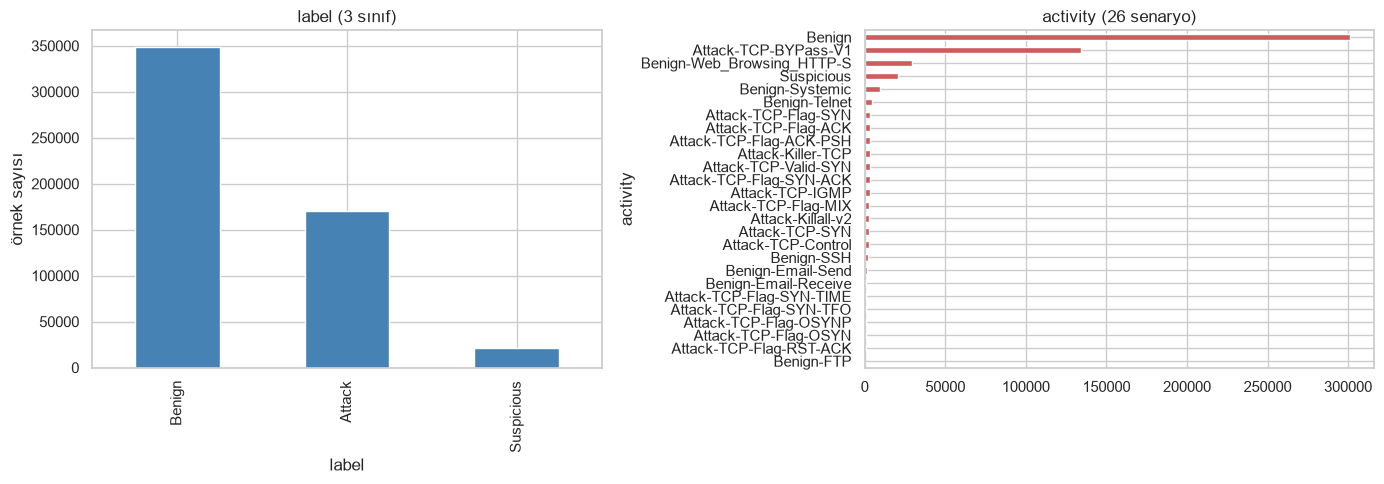

Dengesizlik oranı (en büyük / en küçük sınıf): 16.7x


In [2]:
for col in ["label", "activity"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df["label"].value_counts().plot.bar(ax=ax[0], color="steelblue")
ax[0].set_title("label (3 sınıf)"); ax[0].set_ylabel("örnek sayısı")
df["activity"].value_counts().plot.barh(ax=ax[1], color="indianred")
ax[1].set_title("activity (26 senaryo)"); ax[1].invert_yaxis()
plt.tight_layout(); plt.savefig(FIG / "01_class_distribution.png", dpi=120); plt.show()

imb = df["label"].value_counts()
print(f"Dengesizlik oranı (en büyük / en küçük sınıf): {imb.max() / imb.min():.1f}x")

## 1.2 Veri kalitesi: eksik / sonsuz / sabit değerler

`dhoogla` sürümü zaten temizlenmiş; yine de doğruluyoruz.

In [3]:
num = df.select_dtypes(include=np.number)

n_nan = int((df.isna().sum() > 0).sum())
n_inf = int(np.isinf(num).sum().gt(0).sum())
constant = num.columns[num.nunique() <= 1].tolist()

print(f"NaN içeren sütun sayısı      : {n_nan}")
print(f"inf içeren sayısal sütun     : {n_inf}")
print(f"Sabit (tek değerli) sütunlar : {len(constant)} -> {constant}")

# Neredeyse-sabit sütunlar (tek bir değer örneklerin %99.9'unu kaplıyor)
near_const = [c for c in num.columns
              if num[c].value_counts(normalize=True).iloc[0] > 0.999]
print(f"Neredeyse-sabit (>%99.9) sütun: {len(near_const)}")

NaN içeren sütun sayısı      : 0
inf içeren sayısal sütun     : 0
Sabit (tek değerli) sütunlar : 3 -> ['bwd_urg_flag_counts', 'bwd_urg_flag_percentage_in_total', 'bwd_urg_flag_percentage_in_bwd_packets']


Neredeyse-sabit (>%99.9) sütun: 50


## 1.3 Öznitelik tipleri ve olası sızıntı (leakage) sütunları

`dhoogla` sürümü IP, zaman damgası ve flow_id sütunlarını zaten atmış. Geriye `src_port` /
`dst_port` kalıyor — bunlar testbed kurulumuna aşırı uyum (overfitting) riski taşır;
GA/PSO deneyinde tutup etkisini gözlemleyeceğiz ama raporda not düşeceğiz.

In [4]:
print(df.dtypes.value_counts(), "\n")
leaky = [c for c in df.columns
         if any(k in c.lower() for k in ["ip", "timestamp", "flow_id", "mac", "date"])]
print("IP/timestamp/flow_id benzeri sütun:", leaky or "YOK")
print("Port sütunları:", [c for c in df.columns if "port" in c.lower()])

float32    261
int8        25
int32       20
int16        9
int64        2
str          2
Name: count, dtype: int64 

IP/timestamp/flow_id benzeri sütun: YOK
Port sütunları: ['src_port', 'dst_port']


## 1.4 Öznitelik ölçekleri ve korelasyon

Ölçekler çok farklı (byte sayıları ~1e6, oranlar ~0–1) → normalizasyon şart.
Yüksek korelasyonlu sütun çiftleri, GA/PSO'nun eleyebileceği fazlalığı (redundancy) gösterir.

Ölçek aralığı örnekleri:
                         min          mean           max           std
avg_fwd_bulk_rate        0.0  66966.242188  9.110028e+09  1.373304e+07
fwd_bytes_rate           0.0  64920.441406  4.555014e+09  8.208176e+06
bytes_rate               0.0  72175.304688  4.555014e+09  9.479849e+06
total_payload_bytes      0.0  20249.125221  3.166384e+09  6.977092e+06
bwd_total_payload_bytes  0.0  17294.874761  3.166383e+09  6.642618e+06
                                        min      mean  max       std
mode_fwd_header_bytes_delta_len  -20.000000 -0.017540  0.0  0.432934
min_fwd_header_bytes_delta_len   -36.000000 -0.032259  0.0  0.600512
active_cov                        -1.732000 -0.000014  0.0  0.003865
active_mode                     -454.655914 -0.005529  0.0  1.062497
active_median                   -454.655914 -0.004852  0.0  0.978971


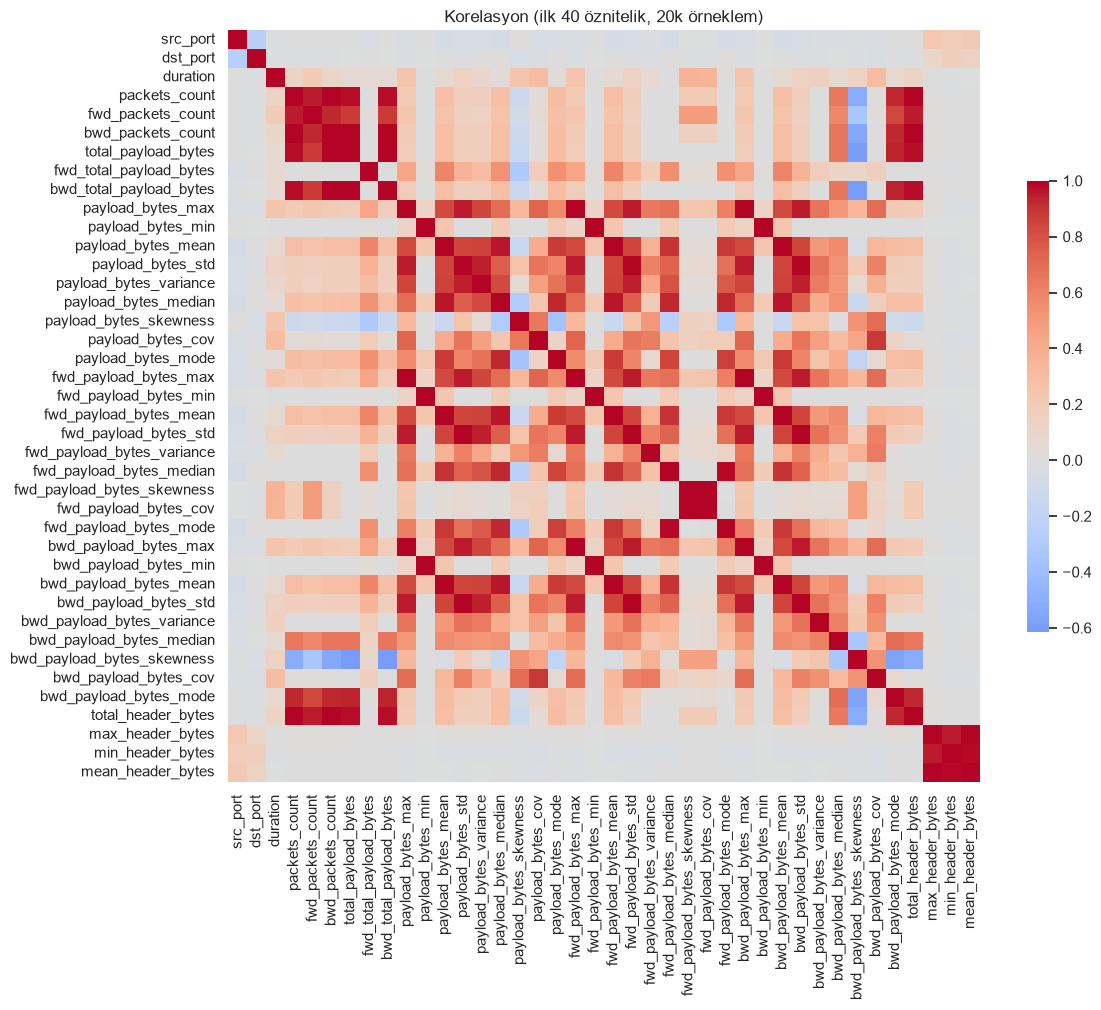


|r| > 0.95 olan öznitelik çifti sayısı: 568


In [5]:
desc = num.describe().T[["min", "mean", "max", "std"]]
print("Ölçek aralığı örnekleri:")
print(desc.sort_values("max", ascending=False).head(5))
print(desc.sort_values("max").head(5))

# Örneklem üzerinde korelasyon ısı haritası (tüm 300+ sütun okunmaz, ilk 40)
sample = num.drop(columns=constant).sample(n=20000, random_state=42)
corr = sample.iloc[:, :40].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6})
plt.title("Korelasyon (ilk 40 öznitelik, 20k örneklem)")
plt.tight_layout(); plt.savefig(FIG / "02_correlation_sample.png", dpi=120); plt.show()

# |r| > 0.95 olan çift sayısı (tüm sayısal sütunlar)
full_corr = sample.corr().abs()
upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))
high_pairs = (upper > 0.95).sum().sum()
print(f"\n|r| > 0.95 olan öznitelik çifti sayısı: {int(high_pairs)}")

## 1.5 EDA özeti (mentöre sunum için)

| Bulgu | Değer | Sonuç |
|---|---|---|
| Boyut | 540.494 satır × 319 sütun (317 öznitelik + 2 etiket) | Yönetilebilir; tam veriyle çalışılabilir |
| Hedef | `label`: Benign / Attack / Suspicious | 3 sınıflı sınıflandırma |
| Sınıf dengesizliği | ~17x (Benign 349k vs Suspicious 21k) | Metrik: **macro-F1** (sadece accuracy değil) |
| Eksik / sonsuz değer | 0 / 0 | Ek temizlik gerekmiyor |
| Sabit sütun | 3 (`bwd_urg_flag_*`) | Atılacak |
| Sızıntı sütunu | IP/timestamp yok; sadece portlar | Portlar tutulacak, raporda not |
| Ölçek farkı | byte sayıları ~1e6, oranlar ~0–1 | **StandardScaler** uygulanacak |
| Yüksek korelasyon | çok sayıda |r|>0.95 çifti | GA/PSO için fazlalık elemine alanı mevcut |

**Sonraki adım:** `src/preprocessing.py` — sabit sütunları at, `label`'ı encode et,
`StandardScaler` uygula, stratified train/test böl, `data/processed/` altına kaydet.